# Time Series Forecasting using ARIMA

Next is to analyze daily temperature data and build forecasting models using statistical time series techniques.

In [ ]:
from google.colab import files
files.upload()

import os

os.makedirs("/root/.kaggle", exist_ok=True)

!mv kaggle.json /root/.kaggle/

!chmod 600 /root/.kaggle/kaggle.json

print("Kaggle configured correctly")

Saving kaggle.json to kaggle.json
Kaggle configured correctly


In [ ]:
!kaggle datasets download -d sumanthvrao/daily-climate-time-series-data

!unzip daily-climate-time-series-data.zip

Dataset URL: https://www.kaggle.com/datasets/sumanthvrao/daily-climate-time-series-data
License(s): CC0-1.0
daily-climate-time-series-data.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  daily-climate-time-series-data.zip
replace DailyDelhiClimateTest.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

## Time Series Data Preparation

We load the dataset, convert the date column into datetime format, and set it as the index for time series analysis.

In [ ]:
import pandas as pd

df_train = pd.read_csv("DailyDelhiClimateTrain.csv")

df_train["date"] = pd.to_datetime(df_train["date"])

df_train.set_index("date", inplace=True)

df_train.head()

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667
2013-01-02,7.400000,92.000000,2.980000,1017.800000
2013-01-03,7.166667,87.000000,4.633333,1018.666667
2013-01-04,8.666667,71.333333,1.233333,1017.166667
2013-01-05,6.000000,86.833333,3.700000,1016.500000


## Time Series Visualization

We visualize temperature trends over time to understand patterns and seasonality.

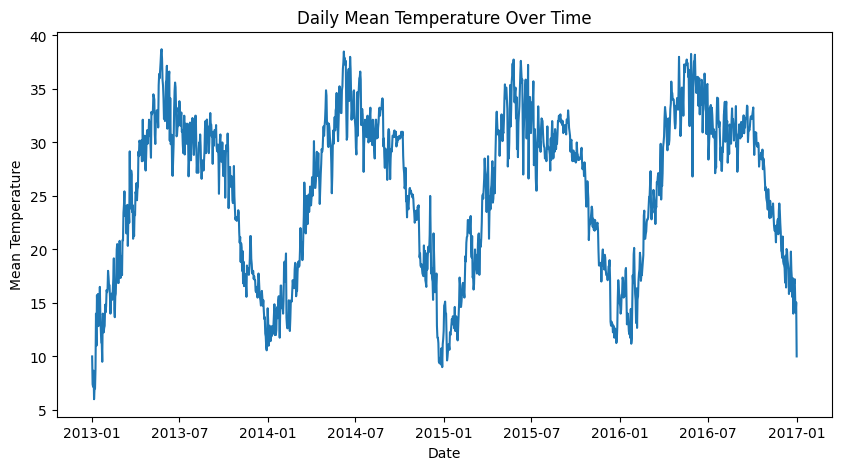

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df_train["meantemp"])
plt.title("Daily Mean Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Mean Temperature")
plt.show()

## Time Series Decomposition

We decompose the time series into three components:
- Trend (long-term movement)
- Seasonality (repeating patterns)
- Residual (random noise)

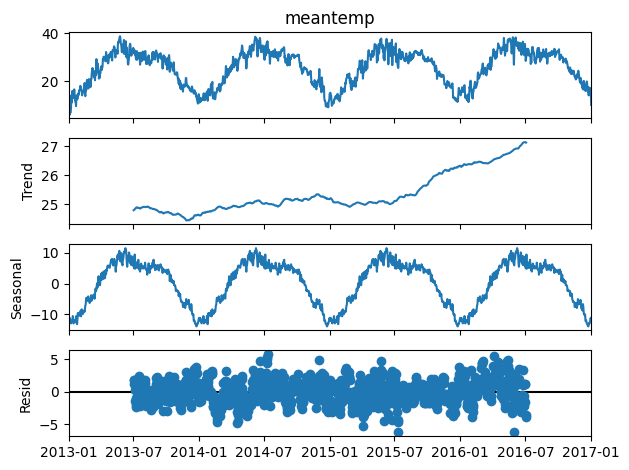

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

decomposition = seasonal_decompose(df_train["meantemp"], model='additive', period=365)

decomposition.plot()
plt.show()

## Moving Average

We apply moving average smoothing to reduce noise and highlight trends.

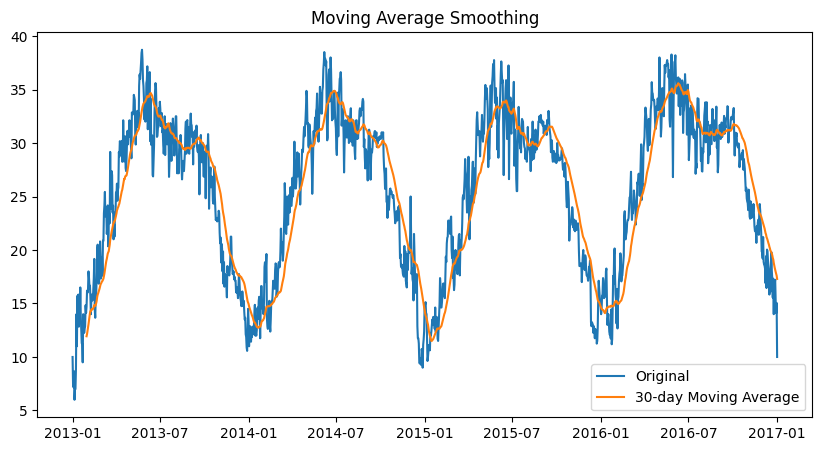

In [ ]:
df_train["MA_30"] = df_train["meantemp"].rolling(window=30).mean()

plt.figure(figsize=(10,5))
plt.plot(df_train["meantemp"], label="Original")
plt.plot(df_train["MA_30"], label="30-day Moving Average")
plt.legend()
plt.title("Moving Average Smoothing")
plt.show()

## Exponential Smoothing

Next to apply exponential smoothing to capture trends while giving more weight to recent observations.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


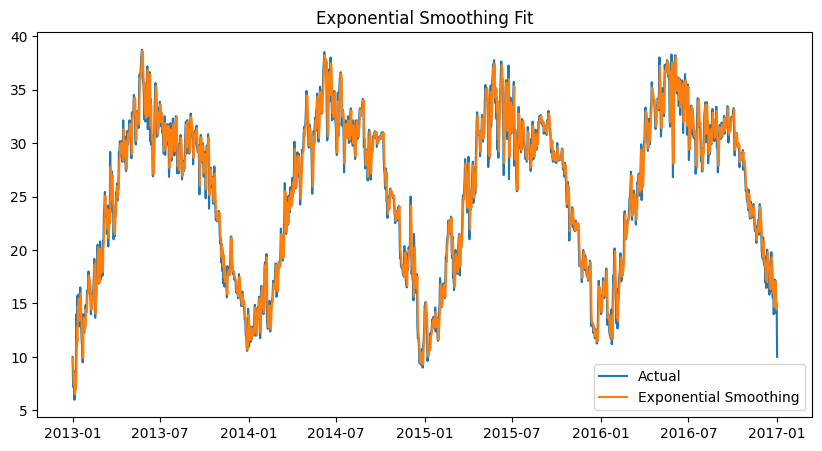

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model_es = ExponentialSmoothing(df_train["meantemp"], trend="add", seasonal=None)
fit_es = model_es.fit()

df_train["ES"] = fit_es.fittedvalues

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df_train["meantemp"], label="Actual")
plt.plot(df_train["ES"], label="Exponential Smoothing")
plt.legend()
plt.title("Exponential Smoothing Fit")
plt.show()

## ARIMA Model for Forecasting

We build an ARIMA model to forecast future temperature values based on past observations.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


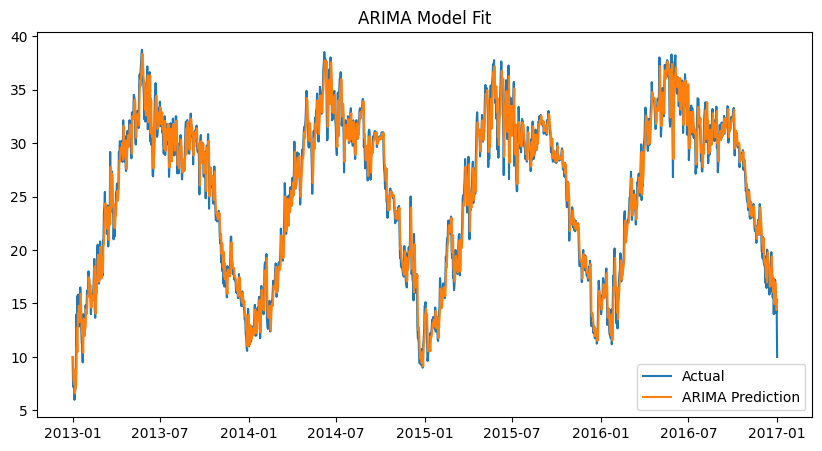

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model_arima = ARIMA(df_train["meantemp"], order=(5,1,0))
fit_arima = model_arima.fit()

df_train["ARIMA_pred"] = fit_arima.predict(start=1, end=len(df_train))

plt.figure(figsize=(10,5))
plt.plot(df_train["meantemp"], label="Actual")
plt.plot(df_train["ARIMA_pred"], label="ARIMA Prediction")
plt.legend()
plt.title("ARIMA Model Fit")
plt.show()

## Model Evaluation (RMSE)

Now to  evaluate forecasting accuracy using Root Mean Squared Error (RMSE).

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(df_train["meantemp"][1:], df_train["ARIMA_pred"][1:]))

print("ARIMA RMSE:", rmse)

ARIMA RMSE: 1.611474921850376


## Future Forecasting

We forecast future temperature values using the trained ARIMA model.

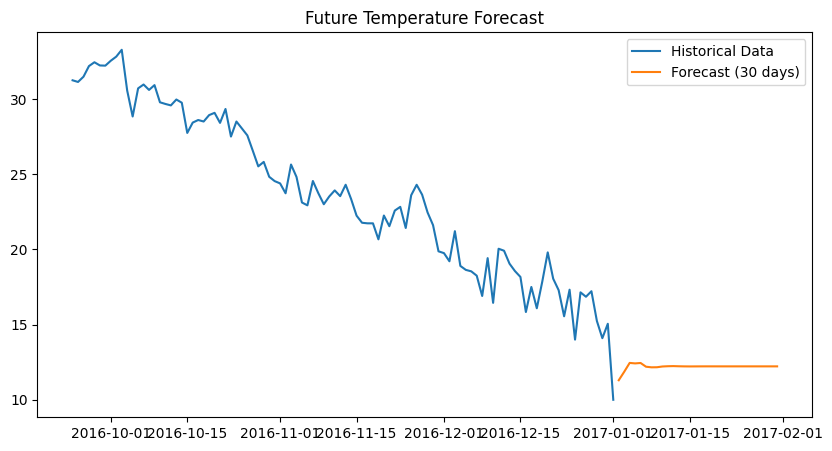

In [ ]:
forecast = fit_arima.forecast(steps=30)

plt.figure(figsize=(10,5))
plt.plot(df_train["meantemp"][-100:], label="Historical Data")
plt.plot(forecast.index, forecast, label="Forecast (30 days)")
plt.legend()
plt.title("Future Temperature Forecast")
plt.show()

## Conclusion
### Key steps:
- Data decomposition revealed trend and seasonal patterns.
- Moving average and exponential smoothing helped reduce noise.
- ARIMA model was used for forecasting future values.
- Model evaluation using RMSE showed forecasting accuracy.

### Final Insight:
The ARIMA model has provided reasonable forecasts and captures the underlying structure of temperature variation over time.